# Electricity Demand and Spot Price Analysis

## 1. Objective

The exploratory analysis identified strong temporal patterns in both electricity
demand and Regional Reference Price (RRP). In particular, demand reaches its
average daily peak at approximately 18:00, while average spot prices peak slightly
earlier at approximately 17:00.

This notebook investigates the relationship between electricity demand and spot
prices more directly. The analysis aims to determine:

- whether higher electricity demand is associated with higher spot prices;
- how strong the demand-price relationship is;
- whether the relationship changes across different demand levels;
- whether extreme price events are associated with unusually high demand; and
- how demand conditions differ during negative-price events.

The analysis focuses on association rather than causation, as electricity prices
may also be influenced by supply conditions, generation mix, network constraints,
weather, and other market factors not included in the current dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/clean_price_demand.csv",
    parse_dates=["SETTLEMENTDATE"]
)

df.head()

,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,NSW1,2026-08-01 00:05:00,8898.91,89.88,TRADE
1,NSW1,2026-08-01 00:10:00,9032.33,95.05,TRADE
2,NSW1,2026-08-01 00:15:00,8989.12,88.88,TRADE
3,NSW1,2026-08-01 00:20:00,9036.72,88.88,TRADE
4,NSW1,2026-08-01 00:25:00,8946.67,84.79,TRADE


## 2. Demand–Price Correlation

As an initial measure of the relationship between electricity demand and spot
prices, the Pearson correlation coefficient is calculated between `TOTALDEMAND`
and `RRP`.

A positive correlation would indicate that higher demand tends to be associated
with higher electricity prices, while a value close to zero would indicate a
weak linear relationship.

In [2]:
correlation = df["TOTALDEMAND"].corr(df["RRP"])

print(f"Correlation between demand and RRP: {correlation:.3f}")

Correlation between demand and RRP: 0.609


## 3. Demand–Price Relationship

The correlation coefficient provides a numerical measure of the linear
association between electricity demand and spot prices, but it does not show
the shape or variability of the relationship.

A scatter plot is therefore used to examine how RRP changes across different
levels of electricity demand and to identify whether extreme price observations
are concentrated at particular demand levels.

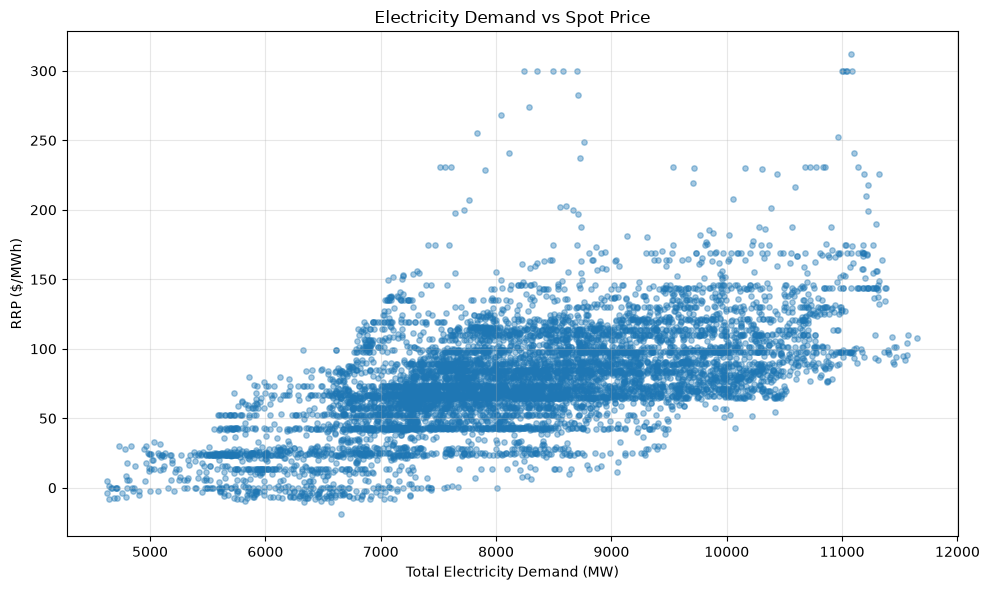

In [3]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["TOTALDEMAND"],
    df["RRP"],
    alpha=0.4,
    s=15
)

plt.xlabel("Total Electricity Demand (MW)")
plt.ylabel("RRP ($/MWh)")
plt.title("Electricity Demand vs Spot Price")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

A scatter plot alone can be quite noisy because you have thousands of five-minute observations. Adding a simple linear trend makes the overall relationship easier to see.

#### Add regression line

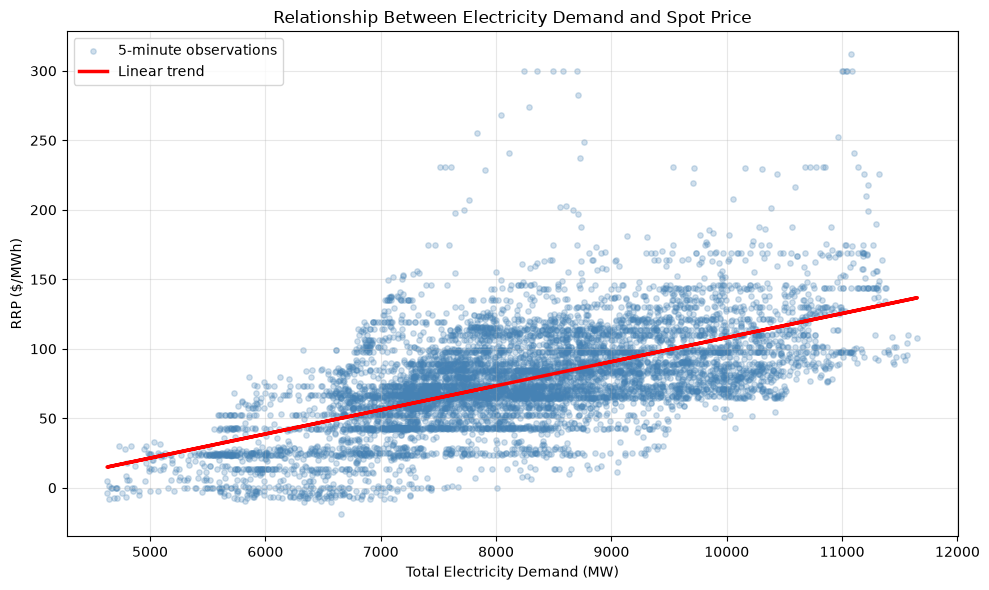

In [6]:
plt.figure(figsize=(10, 6))

plt.scatter(
    x,
    y,
    alpha=0.25,
    s=15,
    color="steelblue",
    label="5-minute observations"
)

plt.plot(
    x,
    slope * x + intercept,
    color="red",
    linewidth=2.5,
    label="Linear trend"
)

plt.xlabel("Total Electricity Demand (MW)")
plt.ylabel("RRP ($/MWh)")
plt.title("Relationship Between Electricity Demand and Spot Price")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
predicted_rrp = slope * x + intercept

ss_res = np.sum((y - predicted_rrp) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)

r_squared = 1 - (ss_res / ss_tot)

print(f"R²: {r_squared:.3f}")

R²: 0.371


### Interpretation

The scatter plot shows a clear positive relationship between electricity demand
and spot prices. As total electricity demand increases, RRP generally tends to
increase, which is reflected by the upward-sloping fitted linear trend.

However, there is substantial variation in RRP at similar levels of demand.
Several extreme price observations above \$200/MWh occur at both moderate and
high demand levels, indicating that high demand is not a necessary condition
for every extreme price event.

The fitted linear relationship produces an **R² of 0.371**, meaning that
approximately **37.1% of the variation in RRP is accounted for by its linear
relationship with electricity demand** in this dataset.

Therefore, electricity demand appears to be an important factor associated with
spot-price behaviour, but demand alone does not fully account for price
variation. Other market conditions not included in this dataset may also be
important, particularly during extreme price events.

## 4. Spot Price Across Demand Levels

The previous analysis identified a positive relationship between electricity
demand and RRP. However, substantial price variation remains at similar demand
levels.

To examine this relationship more clearly, electricity demand is divided into
four quartile-based categories: **Low, Medium, High, and Very High** demand.
Spot-price behaviour is then compared across these groups.

Using quartiles ensures that each demand category contains approximately the
same number of observations.

In [10]:
df["demand_level"] = pd.qcut(
    df["TOTALDEMAND"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

df[["TOTALDEMAND", "demand_level"]].head()

,TOTALDEMAND,demand_level
0,8898.91,High
1,9032.33,High
2,8989.12,High
3,9036.72,High
4,8946.67,High


In [11]:
# Check the number of observations
df["demand_level"].value_counts().sort_index()

demand_level
Low          1944
Medium       1944
High         1944
Very High    1944
Name: count, dtype: int64

In [12]:
# Check the demand range
demand_ranges = (
    df.groupby("demand_level", observed=True)["TOTALDEMAND"]
      .agg(["min", "max", "mean"])
      .round(2)
)

demand_ranges

,min,max,mean
demand_level,,,
Low,4628.03,7297.05,6620.61
Medium,7297.40,8128.90,7709.64
High,8129.11,9112.03,8578.91
Very High,9112.67,11651.75,9934.29


### Demand-Level Classification

Electricity demand is divided into four quartile-based categories, with each
category containing **1,944 observations (25% of the dataset)**:

- **Low demand:** 4,628.03–7,297.05 MW
- **Medium demand:** 7,297.40–8,128.90 MW
- **High demand:** 8,129.11–9,112.03 MW
- **Very High demand:** 9,112.67–11,651.75 MW

The average demand within each category is approximately **6,621 MW**,
**7,710 MW**, **8,579 MW**, and **9,934 MW**, respectively.

Because the categories are based on quartiles rather than manually selected
thresholds, each group contains an equal number of observations. This provides
a balanced basis for comparing spot-price behaviour across progressively higher
levels of electricity demand.

In [13]:
price_by_demand = (
    df.groupby("demand_level", observed=True)["RRP"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)

price_by_demand

,count,mean,median,std,min,max
demand_level,,,,,,
Low,1944,46.43,43.10,31.67,-18.51,153.73
Medium,1944,74.75,71.42,26.75,-1.38,267.96
High,1944,83.81,82.82,30.70,6.06,299.99
Very High,1944,103.25,97.55,33.35,23.95,311.91


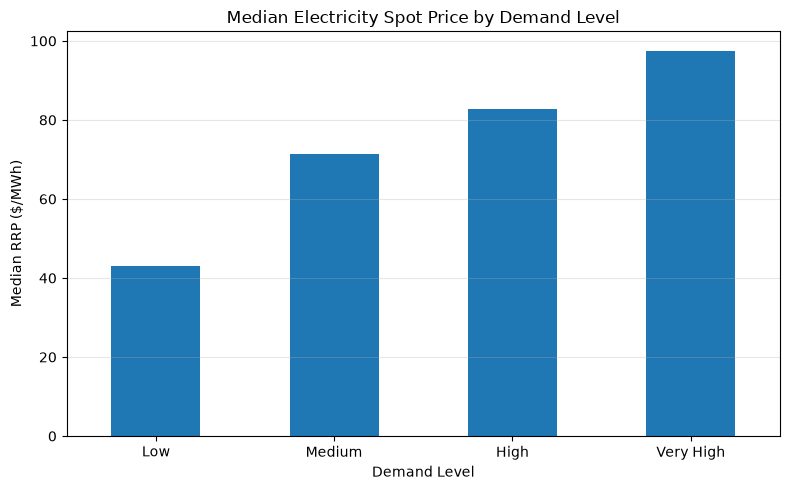

In [14]:
median_price = (
    df.groupby("demand_level", observed=True)["RRP"]
      .median()
)

plt.figure(figsize=(8, 5))

median_price.plot(kind="bar")

plt.xlabel("Demand Level")
plt.ylabel("Median RRP ($/MWh)")
plt.title("Median Electricity Spot Price by Demand Level")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

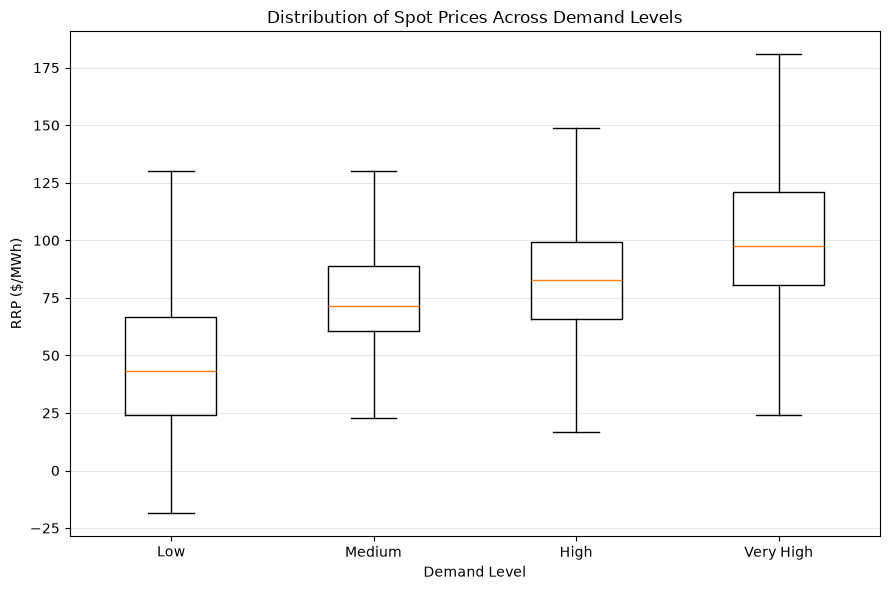

In [15]:
levels = ["Low", "Medium", "High", "Very High"]

data = [
    df.loc[df["demand_level"] == level, "RRP"]
    for level in levels
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    data,
    tick_labels=levels,
    showfliers=False
)

plt.xlabel("Demand Level")
plt.ylabel("RRP ($/MWh)")
plt.title("Distribution of Spot Prices Across Demand Levels")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()